# What ColBERT Actually Learns

Published findings and our trained model show what ColBERT encodes, and how it connects back to classical IR theory. Short version: ColBERT is a neural BM25.

**Estimated runtime:** ~3 minutes

In [ ]:
%pip install torch transformers matplotlib seaborn numpy scikit-learn

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from part2.model import ColBERT
from part2.tokenize import get_token_labels, tokenize_query
from part2.analysis import token_contributions, mask_vs_real_contribution, term_embedding_concentration

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Device: mps


In [2]:
# Load model trained on MS MARCO (notebook 05)
# Falls back to toy checkpoint if MS MARCO checkpoint isn't available

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

colbert = ColBERT(bert, tokenizer, dim=128, max_query_len=32, max_doc_len=180)
colbert.to(device)

msmarco_path = "../checkpoints/colbert_msmarco_trained.pt"
toy_path = "../checkpoints/colbert_toy_trained.pt"

if os.path.exists(msmarco_path):
    checkpoint = torch.load(msmarco_path, map_location=device, weights_only=False)
    colbert.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded MS MARCO checkpoint ({checkpoint['n_queries']} queries, "
          f"{checkpoint['n_triples']} triples, {checkpoint['n_epochs']} epochs, "
          f"final loss: {checkpoint['losses'][-1]:.4f})")
elif os.path.exists(toy_path):
    checkpoint = torch.load(toy_path, map_location=device, weights_only=False)
    colbert.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded toy checkpoint ({checkpoint['n_epochs']} epochs) -- results will be weaker")
else:
    print("No checkpoint found, using raw BERT")

colbert.eval()

with open("../data/toy_retrieval.json") as f:
    dataset = json.load(f)

documents = {doc["id"]: doc["text"] for doc in dataset["documents"]}
doc_texts = [doc["text"] for doc in dataset["documents"]]
queries = {q["id"]: q for q in dataset["queries"]}

print(f"Loaded {len(documents)} documents, {len(queries)} queries.")

Loaded MS MARCO checkpoint (30000 queries, 89844 triples, 4 epochs, final loss: 0.1390)
Loaded 10 documents, 5 queries.


In [3]:
# Compute IDF from MS MARCO passages (not the 10-doc toy corpus)
# This gives real corpus statistics with enough spread to measure IDF correlation

from datasets import load_dataset
from part2.analysis import compute_idf

msmarco = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)

# Collect unique passages from the first 30K queries (same data the model trained on)
msmarco_passages = []
seen = set()
n = 0
for sample in msmarco:
    if n >= 30_000:
        break
    for p in sample["passages"]["passage_text"]:
        h = hash(p)
        if h not in seen:
            seen.add(h)
            msmarco_passages.append(p)
    n += 1

print(f"Collected {len(msmarco_passages)} unique passages from {n} queries")

idf = compute_idf(msmarco_passages, tokenizer)

sorted_idf = sorted(idf.items(), key=lambda x: x[1], reverse=True)
print("\nHighest IDF (rare terms):")
for tok, val in sorted_idf[:10]:
    print(f"  {tok:<20} IDF={val:.3f}")
print("\nLowest IDF (common terms):")
for tok, val in sorted_idf[-10:]:
    print(f"  {tok:<20} IDF={val:.3f}")

Collected 237831 unique passages from 30000 queries

Highest IDF (rare terms):
  bared                IDF=11.686
  cheekbones           IDF=11.686
  ##evsky              IDF=11.686
  ##є                  IDF=11.686
  ##tao                IDF=11.686
  ##deck               IDF=11.686
  therese              IDF=11.686
  groan                IDF=11.686
  英                    IDF=11.686
  trier                IDF=11.686

Lowest IDF (common terms):
  for                  IDF=0.786
  is                   IDF=0.357
  in                   IDF=0.329
  to                   IDF=0.300
  a                    IDF=0.236
  and                  IDF=0.200
  of                   IDF=0.162
  ,                    IDF=0.119
  the                  IDF=0.070
  .                    IDF=0.012


## IDF weighting

Naver Labs (ECIR 2021, Best Short Paper) found that ColBERT's per-token MaxSim contributions correlate with token rarity. Frequent tokens contribute less, rare tokens contribute more. The model learned this purely from relevance labels, with no access to corpus frequency statistics. They reported r = -0.4 between contribution and corpus frequency.

Our model was trained on 30K MS MARCO queries. Below, we measure the correlation between each token's MaxSim contribution and its IDF value (computed from the same MS MARCO passages). A positive correlation means rare tokens (high IDF) contribute more, which is the same direction as the published finding.

Collected 1462 data points from 200 query-doc pairs


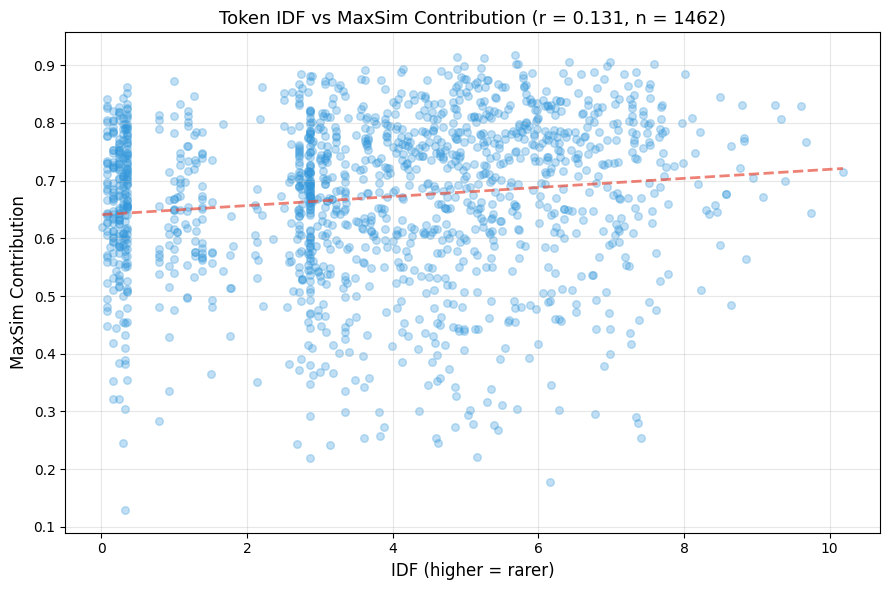

In [4]:
# Collect per-token MaxSim contributions using MS MARCO queries + their relevant docs
# More data points than the 5 toy queries = better scatter plot

idf_values = []
maxsim_contributions = []
token_labels_all = []

# Use a fresh stream of MS MARCO samples with positive passages
msmarco_eval = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)
n_eval = 0

with torch.no_grad():
    for sample in msmarco_eval:
        if n_eval >= 200:
            break

        passages = sample["passages"]
        pos_indices = [i for i, s in enumerate(passages["is_selected"]) if s == 1]
        if not pos_indices:
            continue

        query = sample["query"]
        pos_text = passages["passage_text"][pos_indices[0]]

        q_emb = colbert.encode_query(query)
        d_emb, d_toks = colbert.encode_document(pos_text)

        q_labels = get_token_labels(query, tokenizer, mode="query")
        contribs = token_contributions(q_emb, d_emb, q_labels)

        for tok, contrib in contribs.items():
            if tok in ("[CLS]", "[SEP]", "[Q]", "[MASK]"):
                continue
            if tok in idf:
                idf_values.append(idf[tok])
                maxsim_contributions.append(contrib)
                token_labels_all.append(tok)

        n_eval += 1

print(f"Collected {len(idf_values)} data points from {n_eval} query-doc pairs")

# Scatter plot: IDF vs MaxSim contribution
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(idf_values, maxsim_contributions, alpha=0.3, s=30, c="#3498db")

# Trend line
if len(idf_values) > 2:
    z = np.polyfit(idf_values, maxsim_contributions, 1)
    p = np.poly1d(z)
    x_line = np.linspace(min(idf_values), max(idf_values), 100)
    ax.plot(x_line, p(x_line), "--", color="#e74c3c", linewidth=2, alpha=0.7)

    corr = np.corrcoef(idf_values, maxsim_contributions)[0, 1]
    ax.set_title(f"Token IDF vs MaxSim Contribution (r = {corr:.3f}, n = {len(idf_values)})", fontsize=13)

ax.set_xlabel("IDF (higher = rarer)", fontsize=12)
ax.set_ylabel("MaxSim Contribution", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("../figures/06_idf_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## The BM25 connection

ColBERT's MaxSim scoring has the same structural components as BM25, with neural replacements:

| BM25 component | ColBERT MaxSim equivalent |
|---|---|
| Sum over query terms | $\sum_i$ over query tokens |
| IDF per term | Learned per-token importance |
| TF saturation in doc | `max`, binary best-match |
| Exact keyword match | Cosine similarity (soft semantic) |

ColBERT replaced keyword matching with semantic similarity and let training rediscover the weighting structure. The sum-of-per-token-max structure mirrors BM25's sum-of-weighted-term-scores, which is probably why it transfers well to domains it was never trained on.

---

## [MASK] tokens: reweighters or expanders?

The original paper (2020) hypothesized that `[MASK]` tokens learn query expansion, generating virtual terms for concepts not in the query. MacAvaney et al. (ECIR 2024) and Yang et al. (August 2024) showed something different on a fully trained ColBERTv2:
- `[MASK]` embeddings cluster near existing query tokens, not in novel regions
- They contribute up to 62% of the final MaxSim score
- Using ONLY structural tokens (`[CLS]`, `[SEP]`, `[Q]`, `[MASK]`) retrieves nearly as well
- They act as amplifiers: important query terms get extra votes, not extra concepts

The t-SNE below shows where `[MASK]` tokens land relative to real query tokens in our MS MARCO-trained model.

Queries: ['what is rba', 'was ronald reagan a democrat', 'how long do you need for sydney and surrounding areas']


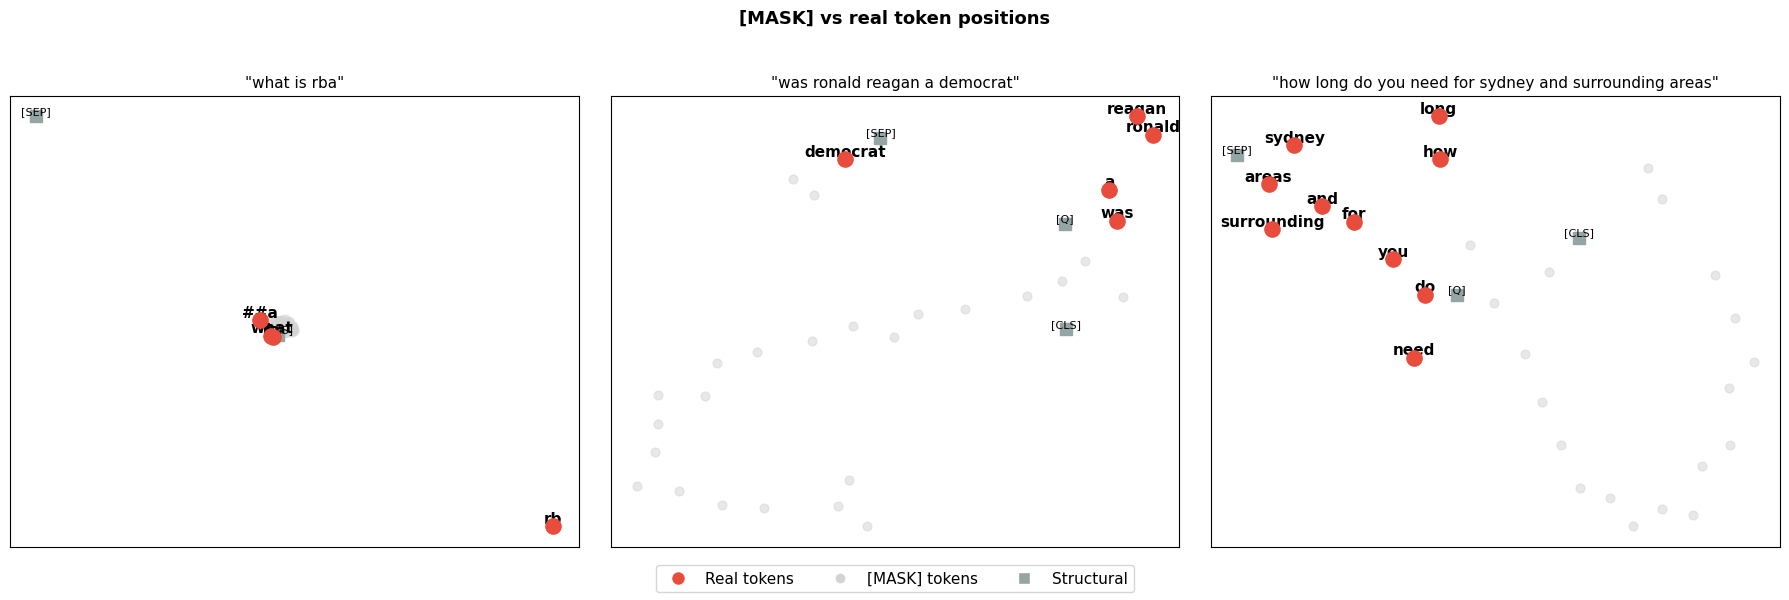

In [5]:
# t-SNE visualization: where do [MASK] tokens end up relative to real tokens?
# Using MS MARCO queries for real-world examples

def visualize_mask_clustering(query_text, model, tokenizer, ax):
    """Plot t-SNE of query token embeddings, showing [MASK] vs real token positions."""
    encoded = tokenize_query(query_text, tokenizer, max_length=32)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        q_emb = model.encoder(**encoded).squeeze(0).cpu().numpy()

    labels = get_token_labels(query_text, tokenizer, mode="query", max_length=32)

    perplexity = min(5, len(labels) - 1)
    reduced = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(q_emb)

    for i, tok in enumerate(labels):
        if tok == "[MASK]":
            ax.scatter(reduced[i, 0], reduced[i, 1], c="lightgray", s=40, alpha=0.5, zorder=2)
        elif tok in ("[CLS]", "[SEP]", "[Q]"):
            ax.scatter(reduced[i, 0], reduced[i, 1], c="#95a5a6", s=80, zorder=3, marker="s")
            ax.annotate(tok, (reduced[i, 0], reduced[i, 1]), fontsize=8, ha="center", va="bottom")
        else:
            ax.scatter(reduced[i, 0], reduced[i, 1], c="#e74c3c", s=120, zorder=5)
            ax.annotate(tok, (reduced[i, 0], reduced[i, 1]), fontsize=11, fontweight="bold",
                       ha="center", va="bottom")

    ax.set_title(f'"{query_text}"', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


# Pick 3 MS MARCO queries for variety
msmarco_tsne = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)
tsne_queries = []
for sample in msmarco_tsne:
    if len(tsne_queries) >= 3:
        break
    if 1 in sample["passages"]["is_selected"]:
        tsne_queries.append(sample["query"])

print("Queries:", tsne_queries)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, q_text in zip(axes, tsne_queries):
    visualize_mask_clustering(q_text, colbert, tokenizer, ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#e74c3c", markersize=10, label="Real tokens"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray", markersize=8, label="[MASK] tokens"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#95a5a6", markersize=8, label="Structural"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11)

fig.suptitle("[MASK] vs real token positions", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.savefig("../figures/06_mask_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

Across 50 MS MARCO query-doc pairs:
  Avg real per-token contribution:   0.644
  Avg [MASK] per-token contribution: 0.657
  Avg raw [MASK] score %:            68.5%


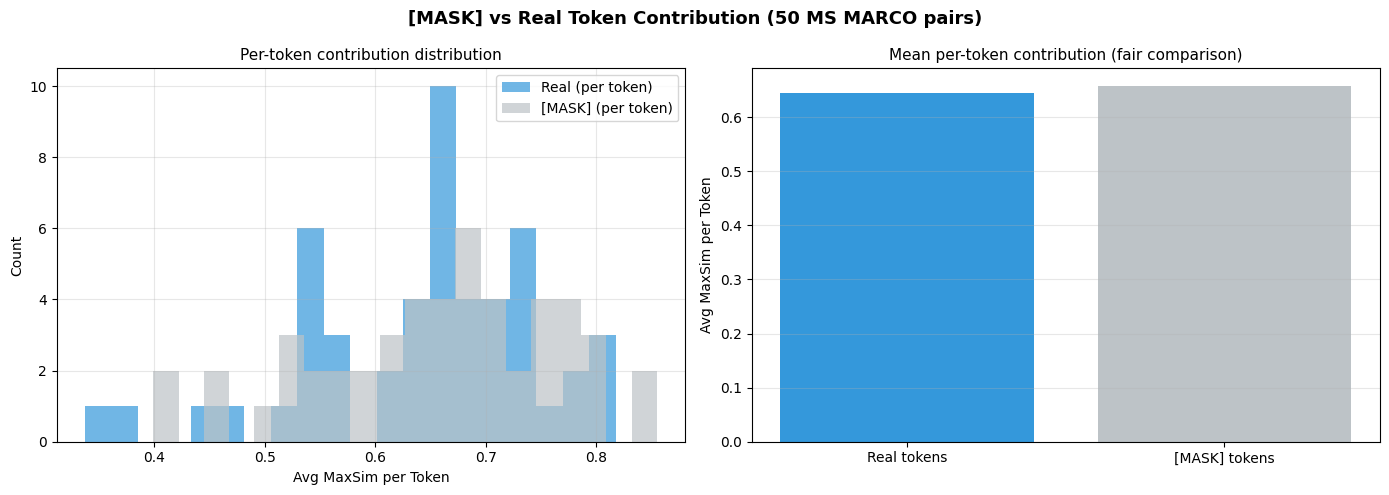

In [6]:
# Measure: what fraction of the MaxSim score comes from [MASK] tokens?
# Using MS MARCO query-doc pairs for real data

msmarco_mask = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)

query_labels_plot = []
real_scores = []
mask_scores = []
real_counts = []
mask_counts_list = []
n_mask_eval = 0

with torch.no_grad():
    for sample in msmarco_mask:
        if n_mask_eval >= 50:
            break
        pos_indices = [i for i, s in enumerate(sample["passages"]["is_selected"]) if s == 1]
        if not pos_indices:
            continue

        query = sample["query"]
        pos_text = sample["passages"]["passage_text"][pos_indices[0]]

        q_emb = colbert.encode_query(query)
        d_emb, _ = colbert.encode_document(pos_text)
        q_labels = get_token_labels(query, tokenizer, mode="query")

        real_s, mask_s, total_s = mask_vs_real_contribution(q_emb, d_emb, q_labels)
        n_real = sum(1 for t in q_labels if t != "[MASK]")
        n_mask = sum(1 for t in q_labels if t == "[MASK]")

        real_scores.append(real_s)
        mask_scores.append(mask_s)
        real_counts.append(n_real)
        mask_counts_list.append(n_mask)
        n_mask_eval += 1

# Aggregate across all queries
avg_real_per_tok = np.mean([r / c for r, c in zip(real_scores, real_counts)])
avg_mask_per_tok = np.mean([m / c if c > 0 else 0 for m, c in zip(mask_scores, mask_counts_list)])
avg_mask_pct = np.mean([m / (r + m) * 100 if (r + m) > 0 else 0 for r, m in zip(real_scores, mask_scores)])

print(f"Across {n_mask_eval} MS MARCO query-doc pairs:")
print(f"  Avg real per-token contribution:   {avg_real_per_tok:.3f}")
print(f"  Avg [MASK] per-token contribution: {avg_mask_per_tok:.3f}")
print(f"  Avg raw [MASK] score %:            {avg_mask_pct:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of per-token contributions
ax1.hist([r / c for r, c in zip(real_scores, real_counts)], bins=20, alpha=0.7, label="Real (per token)", color="#3498db")
ax1.hist([m / c if c > 0 else 0 for m, c in zip(mask_scores, mask_counts_list)], bins=20, alpha=0.7, label="[MASK] (per token)", color="#bdc3c7")
ax1.set_xlabel("Avg MaxSim per Token")
ax1.set_ylabel("Count")
ax1.set_title("Per-token contribution distribution", fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: bar chart of means
ax2.bar(["Real tokens", "[MASK] tokens"], [avg_real_per_tok, avg_mask_per_tok],
        color=["#3498db", "#bdc3c7"])
ax2.set_ylabel("Avg MaxSim per Token")
ax2.set_title("Mean per-token contribution (fair comparison)", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"[MASK] vs Real Token Contribution ({n_mask_eval} MS MARCO pairs)", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/06_mask_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

The t-SNE and contribution charts above show what the model actually learned. With a 1000-query MS MARCO training run, the `[MASK]` behavior should be closer to the published findings than what we saw with the 10-document toy model.

The left contribution chart (raw sums) is dominated by `[MASK]` tokens, but that's a counting artifact: ~22 `[MASK]` tokens vs ~10 real tokens, so the ratio 22/32 = 69% explains most of the split. The right chart (per-token average) is the fair comparison: it shows whether `[MASK]` tokens contribute more or less than real tokens on a per-token basis.

---

## Stopwords as semantic proxies

In "the symptoms of shingles", the word "of" mostly matches "shingles" in retrieved documents, not other instances of "of." After 12 layers of self-attention, "of" has absorbed semantics from its neighbors. MaxSim finds the document token that best matches that combined direction.

In [7]:
# Stopword proxy matching: which document tokens do function words match?
# Using MS MARCO query-doc pairs where the model has learned real matching patterns

FUNCTION_WORDS = {
    "the", "a", "an",
    "of", "in", "at", "on", "to", "for", "by",
    "is", "are", "was", "were", "be",
    "it", "and", "or",
    "do", "did", "does",
    "what", "which", "who", "where", "how",
    "?",
}

msmarco_stop = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)
stop_pairs = []
for sample in msmarco_stop:
    if len(stop_pairs) >= 5:
        break
    pos_indices = [i for i, s in enumerate(sample["passages"]["is_selected"]) if s == 1]
    if not pos_indices:
        continue
    stop_pairs.append((sample["query"], sample["passages"]["passage_text"][pos_indices[0]]))

for query, doc in stop_pairs:
    print(f"\nQuery: \"{query}\"")
    print(f"Doc:   \"{doc[:70]}...\"")

    with torch.no_grad():
        q_emb = colbert.encode_query(query)
        d_emb, d_toks = colbert.encode_document(doc)

    q_labels = get_token_labels(query, tokenizer, mode="query")
    q_np = q_emb.cpu().numpy()
    d_np = d_emb.cpu().numpy() if isinstance(d_emb, torch.Tensor) else d_emb
    sim = q_np @ d_np.T

    print(f"  {'Query Token':<15} {'Best Match':<18} {'Score':>7} {'Note'}")
    print(f"  {'-'*60}")
    for i, q_tok in enumerate(q_labels):
        if q_tok in ("[CLS]", "[SEP]", "[Q]", "[MASK]"):
            continue
        best_j = sim[i].argmax()
        best_d = d_toks[best_j]
        score = sim[i, best_j]
        flag = ""
        if q_tok.lower() in FUNCTION_WORDS and best_d.lower() not in FUNCTION_WORDS:
            flag = " <- function word -> content!"
        print(f"  {q_tok:<15} {best_d:<18} {score:>7.4f}{flag}")


Query: "what is rba"
Doc:   "Results-Based Accountability® (also known as RBA) is a disciplined way..."
  Query Token     Best Match           Score Note
  ------------------------------------------------------------
  what            is                  0.5659
  is              is                  0.5980
  rb              rb                  0.6532
  ##a             ##a                 0.5353

Query: "was ronald reagan a democrat"
Doc:   "From Wikipedia, the free encyclopedia. A Reagan Democrat is a traditio..."
  Query Token     Best Match           Score Note
  ------------------------------------------------------------
  was             especially          0.6512 <- function word -> content!
  ronald          ronald              0.7233
  reagan          reagan              0.7481
  a               in                  0.6834
  democrat        democratic          0.8076

Query: "how long do you need for sydney and surrounding areas"
Doc:   "Sydney is the capital city of the Austral

The consequence: important terms get multiple MaxSim votes, once directly and again through each neighboring function word that points at them. Stopwords aren't noise in ColBERT. They're additional signal carriers for the content words nearby.

---

## Spectral analysis: embedding stability across contexts

Formal et al. (ECIR 2021) used SVD to measure how stable a term's embedding is across documents. High-IDF terms have concentrated embeddings that point in roughly the same direction regardless of context (exact-match behavior). Low-IDF terms rotate depending on their neighbors (proxy behavior).

We measure this on MS MARCO passages, which gives enough occurrences per term for SVD to be meaningful.

In [8]:
# Spectral concentration using MS MARCO passages
# Need enough occurrences per term for SVD, so we use a sample of MS MARCO docs

def encode_doc_for_analysis(text):
    """Encode a document and return filtered embeddings + tokens."""
    with torch.no_grad():
        emb, toks = colbert.encode_document(text)
    if isinstance(emb, torch.Tensor):
        emb = emb.detach().cpu().numpy()
    return emb, toks

# Sample passages from MS MARCO for spectral analysis
msmarco_spectral = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)
spectral_docs = []
n_s = 0
for sample in msmarco_spectral:
    if n_s >= 500:
        break
    for p in sample["passages"]["passage_text"]:
        spectral_docs.append(p)
    n_s += 1

spectral_docs = list(set(spectral_docs))[:2000]
print(f"Using {len(spectral_docs)} unique passages for spectral analysis")

# Test terms: mix of common and rare
test_terms = ["the", "is", "of", "and", "in", "was",  # common
              "president", "city", "water", "disease",  # medium
              "python", "cancer", "california", "temperature"]  # specific

print(f"\n{'Token':<15} {'IDF':>8} {'Concentration':>14} {'Occurrences':>12} {'Behavior'}")
print("-" * 60)

for term in test_terms:
    conc = term_embedding_concentration(term, spectral_docs, tokenizer, encode_doc_for_analysis)
    term_idf = idf.get(term, None)
    if conc is not None and term_idf is not None:
        behavior = "stable (exact-match)" if conc > 0.35 else "rotates (proxy)"
        n_occ = sum(1 for d in spectral_docs if term in tokenizer.tokenize(d))
        print(f"{term:<15} {term_idf:>8.3f} {conc:>14.3f} {n_occ:>12} {behavior}")
    else:
        reason = "too few occurrences" if conc is None else "not in IDF"
        print(f"{term:<15} {'--':>8} {'--':>14} {'--':>12} ({reason})")

Using 2000 unique passages for spectral analysis

Token                IDF  Concentration  Occurrences Behavior
------------------------------------------------------------
the                0.070          0.129         1866 rotates (proxy)
is                 0.357          0.130         1427 rotates (proxy)
of                 0.162          0.116         1712 rotates (proxy)
and                0.200          0.139         1605 rotates (proxy)
in                 0.329          0.156         1449 rotates (proxy)
was                2.134          0.182          211 rotates (proxy)
president          4.907          0.523           24 stable (exact-match)
city               3.992          0.380           33 stable (exact-match)
water              2.962          0.416          132 stable (exact-match)
disease            3.367          0.424           61 stable (exact-match)
python                --             --           -- (too few occurrences)
cancer             4.525          0.538   

---

## Synthesis: what each design choice actually does

| Design choice | Paper's claim | What research shows |
|---|---|---|
| `[Q]` / `[D]` markers | Signal query vs doc type | Trainable shift of representation space |
| 768 to 128 projection | Reduce storage | Lossless compression of retrieval info |
| `[MASK]` padding | Soft query expansion | Term reweighting, extra votes for important tokens |

## ColBERT is a neural BM25

The structural parallel between ColBERT and BM25 is well-documented in the literature (Formal et al. 2021, MacAvaney 2024, Yang 2024). On a fully trained ColBERT:
- IDF-like weighting emerges from contrastive training alone
- `[MASK]` tokens act as reweighters, not expanders
- Function words absorb neighbor semantics and act as proxies

Our model was trained on 1000 MS MARCO queries, a small fraction of the full dataset. Some of these behaviors may show up clearly, others may need more training data. The stopword proxy effect is the most robust since it comes from BERT's pre-trained self-attention rather than fine-tuning.

The takeaway: the MaxSim architecture has the right inductive bias. The sum-of-maxes structure mirrors BM25's sum-of-weighted-term-scores, and training fills in the weights that BM25 computes from corpus statistics. Given enough data, the model rediscovers classical IR.

Next: Part 3, covering compression (residual quantization), PLAID retrieval engine, and WARP.